# Helpers and things I have created for fetching hex maze data

In [1]:
import spyglass.common as sgc
import spyglass.position as sgp
import spyglass.data_import as sgi

from hexmaze import plot_hex_maze
from hex_maze_behavior import HexMazeBlock, HexPosition, HexPath, HexMazeChoice, HexMazeTrialHistory
from berke_fiber_photometry import FiberPhotometrySeries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[2025-11-20 18:51:49,589][INFO]: DataJoint 0.14.6 connected to yshwang@lmf-db.cin.ucsf.edu:3306


## Fetch data from `HexMazeBlock` and `HexMazeBlock.Trial` tables

Both of these tables have the secondary key `interval_list_name`, so we can't do a regular join using `*`.

I have a function `HexMazeBlock().join_with_trial()` that automatically renames these to `block_interval_list_name` and `trial_interval_list_name` so we can join them

In [ ]:
nwb_file_name = 'IM-1594_20230725_.nwb'
sgc.Session() & {'nwb_file_name': nwb_file_name}

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
IM-1594_20230727_.nwb,IM-1594,"University of California, San Francisco",Berke Lab,IM-1594_20230727,probability change session for the hex maze task with 3 blocks and 138 trials.,2023-07-27 13:40:37,2023-07-27 13:40:37,Hex maze task


In [3]:
nwb_file_name = 'IM-1594_20230727_.nwb'
HexPosition() & {'nwb_file_name': nwb_file_name}
#HexPath.populate({'nwb_file_name': nwb_file_name})

pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_assignment_object_id
68b019b3-af1d-92a4-742b-1dad39885524,IM-1594_20230727_.nwb,0,IM-1594_20230727_13VNH7VY7P.nwb,38ab0a05-296b-438b-a085-962d28c09737


In [4]:
# mannually specify pos_merge_id
pos_merge_id = "68b019b3-af1d-92a4-742b-1dad39885524"

# Example of fetching data from HexPath table
hex_path_key = {"pos_merge_id": pos_merge_id}
display(HexPath() & hex_path_key)

# Get hex path dataframe for the whole epoch
epoch_df = (HexPath & hex_path_key).fetch1_dataframe()
display(epoch_df)

pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_path_object_id
68b019b3-af1d-92a4-742b-1dad39885524,IM-1594_20230727_.nwb,0,IM-1594_20230727_DLLNOM7WTS.nwb,08b8de98-b1a2-46e1-bb4b-ea36ed39f695


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion
id,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen
3905,IM-1594_20230727_.nwb,0,3,12,138,5,6665.001283,6665.208629,0.207346,17,1,12,2,optimal,chosen


# *RAMP Pipeline*
1. Calculate average `z_scored_green_dFF` between each hex's `entry_time` and `exit_time` and add that column
2. Plot the ramp approaching to the goal (first, all of trials)
3. Get trial information based on conditions (rewarded? unrewarded? swr? no-swr? unrewarded_rewarded? rewarded_unrewarded?)
4. Plot the ramp given that information of trials

### 1.  Calculate average `z_scored_green_dFF` between each hex's `entry_time` and `exit_time` and add that column

In [5]:
def add_averaged_series_column(HexPath_df, phot_series, new_col_name: str):
    """
    Calculate the average z_scored_green_dFF between each hex's entry_time and exit_time.

    Parameters:
    HexPath_df (pd.DataFrame): DataFrame containing hex path data with 'entry_time' and 'exit_time' columns.
    phot_series (FiberPhotometryResponseSeries): Photometry series object containing timestamps and data.

    Returns:
    pd.DataFrame: Updated DataFrame with a new column specified by col_name.
    """
    df = HexPath_df.copy()
    avg_series_list = []

    timestamps = phot_series.get_timestamps()
    data = phot_series.data[:]

    for _, row in df.iterrows():
        entry_time = row['entry_time']
        exit_time = row['exit_time']

        # Find indices of timestamps within the entry and exit time
        indices = np.where((timestamps >= entry_time) & (timestamps <= exit_time))[0]

        if len(indices) > 0:
            avg_dFF = np.mean(data[indices])
        else:
            avg_dFF = np.nan  # No data in this interval

        avg_series_list.append(avg_dFF)

    df[new_col_name] = avg_series_list
    return df

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion
id,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen
3905,IM-1594_20230727_.nwb,0,3,12,138,5,6665.001283,6665.208629,0.207346,17,1,12,2,optimal,chosen


Text(0, 0.5, 'Photometry series data')

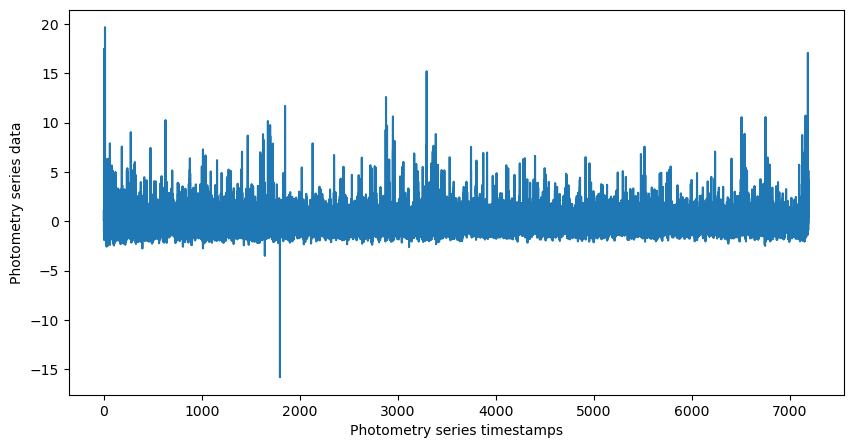

In [6]:
# Get hex path dataframe for the whole epoch
epoch_df = (HexPath & hex_path_key).fetch1_dataframe()
display(epoch_df)

# Fetch the a specific nwb FiberPhotometryResponseSeries object by name
series_name = "z_scored_green_dFF"
phot_series = FiberPhotometrySeries.fetch_series(nwb_file_name=nwb_file_name, series_name=series_name)

plt.figure(figsize = (10, 5))
plt.plot(phot_series.get_timestamps(), phot_series.data[:])
plt.xlabel('Photometry series timestamps')
plt.ylabel('Photometry series data')

In [7]:
epoch_df_dff = add_averaged_series_column(epoch_df, phot_series, new_col_name='avg_z_scored_green_dFF')
display(epoch_df_dff)

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen,1.479858
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen,3.024351
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen,3.472468
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen,2.117566
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen,3.492153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen,-0.200930
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen,-0.035684
3905,IM-1594_20230727_.nwb,0,3,12,138,5,6665.001283,6665.208629,0.207346,17,1,12,2,optimal,chosen,0.365923


In [8]:
def filter_df_by_duration(HexPath_df, max_duration: float = 1.0):
    """
    Filter epochs based on minimum duration.
    """
    df = HexPath_df.copy()
    filtered_df = df[df['duration'] <= max_duration]
    
    return filtered_df

In [9]:
epoch_df_dff_duration_filtered = filter_df_by_duration(epoch_df_dff, max_duration = 1)
epoch_df_dff_duration_filtered

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen,1.479858
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen,3.024351
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen,3.472468
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen,2.117566
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen,3.492153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3902,IM-1594_20230727_.nwb,0,3,12,138,13,6664.324267,6664.526505,0.202238,14,1,9,5,optimal,chosen,0.179435
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen,-0.200930
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen,-0.035684


### 2. Plot the ramp approaching to the goal (first, all of trials)
- epoch_df_dff has `hexes_from_end`, `hex_type`, and `hex_entry_num` to filter the hex to combine the `avg_z_scored_green_dff`
- we average the `avg_z_scored_green_dff` on the same of `hexes_from_end` when `'hex_type' == 'optimal'`, for now, ignore `hex_entry_num`

In [10]:
def weighted_mean_and_sem(HexPath_df, series_col: str = 'avg_z_scored_green_dFF', duration_col: str = 'duration'):
    """
    Compute duration-weighted mean and an approximate weighted SEM for one DataFrame (no grouping).
    Returns a pandas Series with keys: weighted_mean, weighted_sem, count, total_duration.
    """
    # drop rows with missing values in either column
    df = HexPath_df.dropna(subset=[series_col, duration_col])
    x = df[series_col].to_numpy(dtype=float)
    w = df[duration_col].to_numpy(dtype=float)
    n = x.size
    sum_w = w.sum()

    if n == 0:
        return pd.Series({'weighted_mean': np.nan, 'weighted_sem': np.nan, 'count': 0, 'total_duration': 0.0})

    # if total weight is zero we cannot compute a weighted mean/sem
    if sum_w == 0:
        return pd.Series({'weighted_mean': np.nan, 'weighted_sem': np.nan, 'count': int(n), 'total_duration': float(sum_w)})

    # weighted mean
    weighted_mean = np.average(x, weights=w)

    # population weighted variance: sum(w*(x-mu)^2)/sum(w)
    wvar = np.average((x - weighted_mean) ** 2, weights=w)
    sum_w2 = (w ** 2).sum()

    # effective sample size and sem
    n_eff = (sum_w ** 2) / sum_w2 if sum_w2 > 0 else np.nan
    weighted_sem = np.sqrt(wvar / n_eff) if (not np.isnan(n_eff) and n_eff > 0) else np.nan

    return pd.Series({
        'weighted_mean': float(weighted_mean),
        'weighted_sem': float(weighted_sem),
        'count': int(n),
        'total_duration': float(sum_w)
    })

In [11]:
def group_series_by_hexes_from_end(HexPath_df, series_col: str, hex_type=['optimal', 'non_optimal', 'dead_end'], maze_portion=['chosen', 'start', 'choice_point', 'unchosen'], pick_max_hex_entry_num=False):
    """
    Group series_name by hexes_from_end for rows with given hex_type.

    Parameters:
    - HexPath_df: pd.DataFrame with columns ['block','block_trial_num','hexes_from_end',
      'hex_type','hex_entry_num','averaged_series (manual column name)']
    - hex_type: filter by these hex_types, they have ['optimal', 'dead_end', 'non_optimal'] (default ['optimal'])
    - pick_max_hex_entry_num: if True, for each (block, block_trial_num, hexes_from_end)
      keep only the row with the max hex_entry_num (useful to pick last revisit)

    Returns:
    - dict mapping hexes_from_end -> list of series_col (NaNs are dropped)
    """

    df = HexPath_df.copy()

    if pick_max_hex_entry_num:
        # keep the last visit per trial/hexes_from_end (largest hex_entry_num)
        df = df.sort_values('hex_entry_num').drop_duplicates(
            subset=['block', 'block_trial_num', 'hexes_from_end'],
            keep='last'
        )

    # filter by hex_type
    if hex_type:
        df = df[df['hex_type'].isin(hex_type)]

    if maze_portion:
        df = df[df['maze_portion'].isin(maze_portion)]

    # group by hexes_from_end and 
    series_by_hexes_from_end = (df
             .groupby('hexes_from_end')
             .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))

    return series_by_hexes_from_end

In [12]:
# testing the data that passed the duration filter
dff_by_hexes_from_end = group_series_by_hexes_from_end(epoch_df_dff_duration_filtered, series_col='avg_z_scored_green_dFF', hex_type=['optimal'])
display(dff_by_hexes_from_end)

/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,0.224267,0.093540,22.0,18.174292
1,0.581165,0.102051,128.0,20.256757
2,0.445795,0.106179,123.0,26.968004
3,0.479163,0.107510,100.0,21.640218
4,0.487285,0.092577,124.0,43.021202
5,0.358545,0.077271,132.0,36.433387
6,0.243873,0.078530,146.0,58.102269
7,0.412664,0.082975,165.0,63.273263
8,0.177088,0.061258,182.0,75.637931


In [13]:
def plot_series_during_port_approach(series_by_hexes_from_end, series_col:str='weighted_mean', exclude_end_port=False, max_hexes_from_end=False, plot_sem=True, figsize=(10,5), figtitle:str='Mean z-scored green dFF'):

    df = series_by_hexes_from_end.copy()
    
    if exclude_end_port:
        df = df.loc[df.index != 0]

    if max_hexes_from_end:
        df = df.loc[df.index <= max_hexes_from_end]
        
    plt.figure(figsize=figsize)
    plt.plot(df.index, df[series_col], label=series_col, color='C2')
    if plot_sem:
        plt.fill_between(df.index, df[series_col] - df['weighted_sem'], df[series_col] + df['weighted_sem'], color='C2', alpha=0.25, label='± weighted sem')
    plt.xlabel('Distance from port (hexes)')
    plt.ylabel(figtitle) # TODO: what if I want to plot the speed? how this function adjustable?
    # reverse x axis so it goes from max -> min
    plt.xlim(df.index.max(), df.index.min())
    plt.xticks(np.arange(df.index.max(), df.index.min()-1, -1))
    plt.legend()
    plt.show()

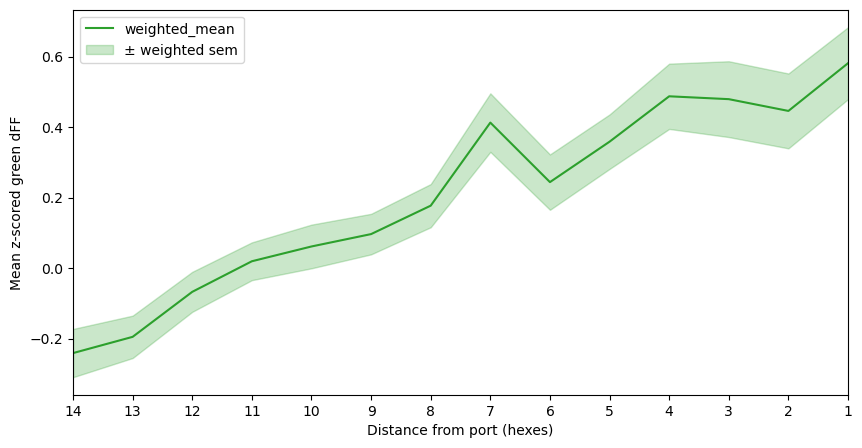

In [14]:
plot_series_during_port_approach(dff_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=True, max_hexes_from_end=14) 

# Back To *RAMP* with Steph's newly populated table!
### 3. Get trial information based on conditions (rewarded? unrewarded? swr? no-swr? unrewarded_rewarded? rewarded_unrewarded?)

In [15]:
nwb_file_name = 'IM-1478_20220726_.nwb'
TrialHistory_df = pd.DataFrame((HexMazeTrialHistory() * HexMazeChoice() * HexMazeBlock().join_with_trial() & {'nwb_file_name': nwb_file_name}).fetch(as_dict=True)) # * sgc.Session()
TrialHistory_df.head()

,nwb_file_name,epoch,block,block_trial_num,port_visit_1prev_rwd,port_visit_2prev_rwd,port_visit_3prev_rwd,port_visit_1prev_same_path,port_visit_2prev_same_path,port_visit_3prev_same_path,...,num_trials,task_type,trial_interval_list_name,epoch_trial_num,reward,start_port,end_port,opto_cond,poke_interval,duration
0,IM-1478_20220726_.nwb,0,1,2,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial2,2,0,B,A,None,"[69.228, 74.12250240000337]",19.7859
1,IM-1478_20220726_.nwb,0,1,3,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial3,3,0,A,B,None,"[106.528, 108.44085760000348]",34.3184
2,IM-1478_20220726_.nwb,0,1,4,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial4,4,1,B,C,None,"[132.54, 140.2933951999992]",31.8525
3,IM-1478_20220726_.nwb,0,1,5,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial5,5,0,C,B,None,"[152.896, 164.43391999999434]",24.1405
4,IM-1478_20220726_.nwb,0,1,6,0,0,0,1,0,0,...,62,probability change,epoch0_block1_trial6,6,1,B,A,None,"[174.56, 189.60823039999605]",25.1743


In [16]:
def get_prev_current_dfs_by_conditions(
    HexPath_df: pd.DataFrame,
    HexMazeTrialHistory_df: pd.DataFrame,
    conditions: dict = None,
    *,
    skip_missing_filter_columns: bool = True,
) :
    """
    Return (prev_trial_df, current_trial_df) filtered from HexMazeTrialHistory_df according
    to the provided condition lists. Each parameter corresponds to a column in
    HexMazeTrialHistory_df and is used with `.isin(...)` when not None.

    prev_trial_df contains the rows whose `epoch_trial_num` equals
    current_trial_df['epoch_trial_num'] - 1 (i.e., the immediate previous trial).
    Both returned DataFrames are sorted by 'epoch_trial_num'.

    Parameters:
    - HexMazeTrialHistory_df: DataFrame with trial history (must contain relevant columns
      including 'epoch_trial_num').
    - Any of the keyword parameters: list of allowed values for that column. If
      a parameter is None, that column is not used for filtering.

    Returns:
    - prev_trial_df, current_trial_df (both pd.DataFrame)
    """
    hex_df = HexPath_df.copy()
    trial_df = HexMazeTrialHistory_df.copy() 
    
    if 'epoch_trial_num' not in trial_df.columns or 'epoch_trial_num' not in hex_df.columns:
        raise ValueError("Both inputs must contain 'epoch_trial_num'")

    # Apply filters based on provided conditions 
    for col, allowed_values in conditions.items():
        if allowed_values is not None:
            trial_df = trial_df[trial_df[col].isin(allowed_values)]
            
    # Create current and previous trial DataFrames
    current_epoch_trial_num = trial_df.epoch_trial_num.values
    prev_epoch_trial_num = current_epoch_trial_num - 1
    
    print(f"Total previous/current trials after filtering: {len(current_epoch_trial_num)} each")
    
    current_HexPath_df = hex_df[hex_df['epoch_trial_num'].isin(current_epoch_trial_num)].copy()
    prev_HexPath_df = hex_df[hex_df['epoch_trial_num'].isin(prev_epoch_trial_num)].copy()
    
    return prev_HexPath_df, current_HexPath_df
    

In [17]:
conditions_to_filter = {
    'port_visit_2prev_rwd': [0],
    'port_visit_1prev_rwd': [1],
    'trials_since_port_visit' : [2, 3],
}

prev_epoch_df_dff_duration_condition_filtered, current_epoch_df_dff_duration_condition_filtered = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_to_filter)
print(conditions_to_filter)
display(prev_epoch_df_dff_duration_condition_filtered.head())
display(current_epoch_df_dff_duration_condition_filtered.head())    

Total previous/current trials after filtering: 17 each
{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
95,IM-1594_20230727_.nwb,0,1,6,6,3,111.348578,111.412658,0.064080,3,2,0,16,optimal,start,-0.045670
96,IM-1594_20230727_.nwb,0,1,6,6,48,111.492646,112.116502,0.623856,4,2,1,15,optimal,start,0.108603
97,IM-1594_20230727_.nwb,0,1,6,6,33,112.205884,112.532363,0.326479,5,1,2,14,optimal,start,1.184275
98,IM-1594_20230727_.nwb,0,1,6,6,28,112.599016,113.222014,0.622998,6,1,3,13,optimal,start,1.124024
99,IM-1594_20230727_.nwb,0,1,6,6,34,113.302258,113.508461,0.206203,7,1,4,12,optimal,start,-0.029188


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
112,IM-1594_20230727_.nwb,0,1,7,7,2,123.173962,123.940091,0.766129,1,1,0,14,optimal,start,-0.567875
113,IM-1594_20230727_.nwb,0,1,7,7,49,124.020843,124.708140,0.687296,2,1,1,13,optimal,start,0.021712
114,IM-1594_20230727_.nwb,0,1,7,7,47,124.775798,125.267249,0.491451,3,1,2,14,dead_end,start,0.557664
115,IM-1594_20230727_.nwb,0,1,7,7,49,125.331196,125.970276,0.639081,4,2,1,13,optimal,start,0.316877
116,IM-1594_20230727_.nwb,0,1,7,7,38,126.035144,126.188611,0.153466,5,1,2,12,optimal,start,0.062504


#### 4. Plot the ramp given that information of trials

In [18]:
prev_dff_by_hexes_from_end = group_series_by_hexes_from_end(prev_epoch_df_dff_duration_condition_filtered, series_col = 'avg_z_scored_green_dFF', hex_type=['optimal'])
current_dff_by_hexes_from_end = group_series_by_hexes_from_end(current_epoch_df_dff_duration_condition_filtered, series_col = 'avg_z_scored_green_dFF', hex_type=['optimal'])
print(conditions_to_filter)
print(prev_dff_by_hexes_from_end)
print(current_dff_by_hexes_from_end)

{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}
                weighted_mean  weighted_sem  count  total_duration
hexes_from_end                                                    
0                    0.702715      0.004029    2.0        1.584168
1                    0.495656      0.146212   16.0        2.585957
2                    0.055432      0.301768   16.0        3.918992
3                    0.294316      0.222285   11.0        2.122166
4                    0.151194      0.098380   15.0        5.389052
5                    0.241264      0.211111   13.0        5.246862
6                   -0.001888      0.109358   28.0       11.939079
7                    0.089038      0.154466   30.0       13.427930
8                    0.237322      0.209394   20.0        9.028433
9                   -0.009975      0.140920   21.0       10.340244
10                  -0.025464      0.125803   20.0        6.670047
11                  -0.177281      

/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))
/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))


In [19]:
def plot_two_series_during_port_approach(prev_series_by_hexes_from_end, current_series_by_hexes_from_end, series_col:str='weighted_mean', exclude_end_port=False, max_hexes_from_end=False, plot_sem=True, figsize=(10,5), figtitle:str='Average z-scored green dFF'):

    prev_df = prev_series_by_hexes_from_end.copy()
    current_df = current_series_by_hexes_from_end.copy()
    
    if exclude_end_port:
        prev_df = prev_df.loc[prev_df.index != 0]
        current_df = current_df.loc[current_df.index != 0]

    if max_hexes_from_end:
        prev_df = prev_df.loc[prev_df.index <= max_hexes_from_end]
        current_df = current_df.loc[current_df.index <= max_hexes_from_end]
        
    plt.figure(figsize=figsize)
    plt.plot(prev_df.index, prev_df[series_col], label='Previous', color='C7')
    plt.plot(current_df.index, current_df[series_col], label='Current', color='C0')
    if plot_sem:
        plt.fill_between(prev_df.index, prev_df[series_col] - prev_df['weighted_sem'], prev_df[series_col] + prev_df['weighted_sem'], color='C7', alpha=0.25, label='± weighted sem')
        plt.fill_between(current_df.index, current_df[series_col] - current_df['weighted_sem'], current_df[series_col] + current_df['weighted_sem'], color='C0', alpha=0.25, label='± weighted sem')
    plt.xlabel('Hexes from end')
    plt.ylabel(figtitle)
    # reverse x axis so it goes from max -> min
    plt.xlim(prev_df.index.max(), prev_df.index.min())
    plt.xticks(np.arange(prev_df.index.max(), prev_df.index.min()-1, -1))
    plt.legend()
    plt.show()

{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}


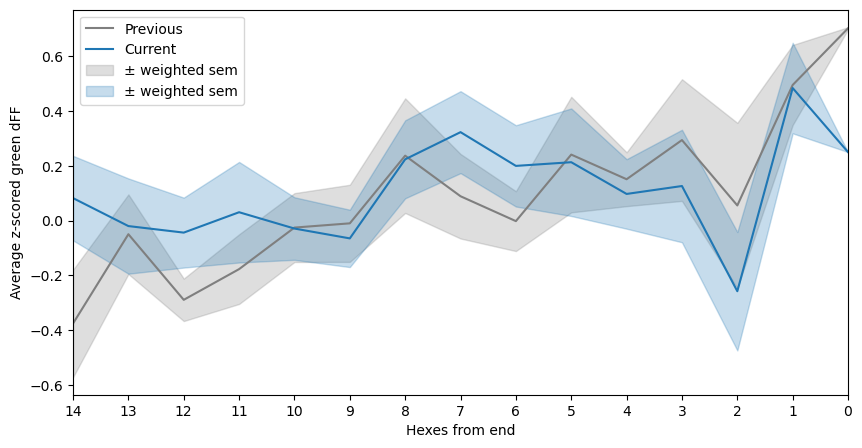

In [20]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}


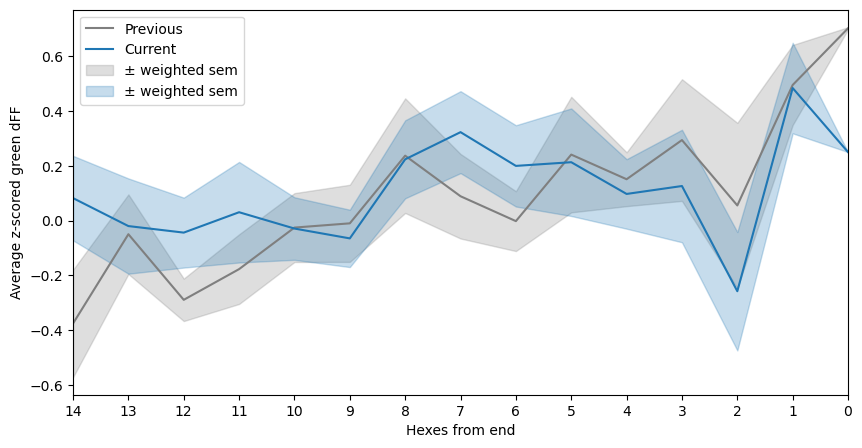

In [21]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

### trying another condition

In [22]:
conditions_to_filter = {
    'port_visit_2prev_rwd': [1],
    'port_visit_1prev_rwd': [0],
    'trials_since_port_visit' : [2, 3],
}

prev_epoch_df_dff_duration_condition_filtered, current_epoch_df_dff_duration_condition_filtered = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_to_filter)
print(conditions_to_filter)
display(prev_epoch_df_dff_duration_condition_filtered.head())
display(current_epoch_df_dff_duration_condition_filtered.head())    

Total previous/current trials after filtering: 18 each
{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
266,IM-1594_20230727_.nwb,0,1,12,12,48,307.501610,307.554690,0.053080,2,1,1,15,optimal,start,-0.398321
267,IM-1594_20230727_.nwb,0,1,12,12,3,307.632856,307.696572,0.063716,3,2,0,16,optimal,start,-0.283781
268,IM-1594_20230727_.nwb,0,1,12,12,48,307.778015,308.051617,0.273602,4,2,1,15,optimal,start,0.180281
269,IM-1594_20230727_.nwb,0,1,12,12,3,308.112581,308.803409,0.690827,5,3,0,16,optimal,start,1.156701
273,IM-1594_20230727_.nwb,0,1,12,12,43,316.590855,316.996561,0.405706,9,1,2,16,dead_end,start,1.869890


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
293,IM-1594_20230727_.nwb,0,1,13,13,38,328.432921,328.712464,0.279543,3,1,2,14,optimal,start,-0.039968
294,IM-1594_20230727_.nwb,0,1,13,13,32,328.801456,328.994324,0.192867,4,1,3,13,optimal,start,-0.547466
295,IM-1594_20230727_.nwb,0,1,13,13,27,329.056250,329.269349,0.213100,5,1,4,12,optimal,start,-0.391921
296,IM-1594_20230727_.nwb,0,1,13,13,22,329.327411,329.615144,0.287733,6,1,5,11,optimal,start,-1.240783
298,IM-1594_20230727_.nwb,0,1,13,13,31,331.136020,331.981227,0.845207,8,1,7,9,optimal,chosen,-0.658267


In [23]:
prev_dff_by_hexes_from_end = group_series_by_hexes_from_end(prev_epoch_df_dff_duration_condition_filtered, series_col = 'avg_z_scored_green_dFF', hex_type=['optimal'])
current_dff_by_hexes_from_end = group_series_by_hexes_from_end(current_epoch_df_dff_duration_condition_filtered, series_col = 'avg_z_scored_green_dFF', hex_type=['optimal'])
print(conditions_to_filter)
print(prev_dff_by_hexes_from_end)
print(current_dff_by_hexes_from_end)

{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}
                weighted_mean  weighted_sem  count  total_duration
hexes_from_end                                                    
0                    0.513245      0.231283    3.0        2.533715
1                    0.389710      0.207231   15.0        2.354942
2                    0.448493      0.307428   17.0        3.420138
3                    0.382387      0.304130   14.0        3.083510
4                    0.537101      0.222733   15.0        4.745485
5                    0.530760      0.195743   17.0        4.455438
6                    0.137132      0.137284   23.0        9.630248
7                    0.578159      0.196105   27.0       11.396649
8                    0.207356      0.192739   21.0        9.405403
9                    0.137359      0.107222   40.0       14.826707
10                   0.235332      0.136095   33.0       11.851553
11                   0.093199      

/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))
/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))


{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}


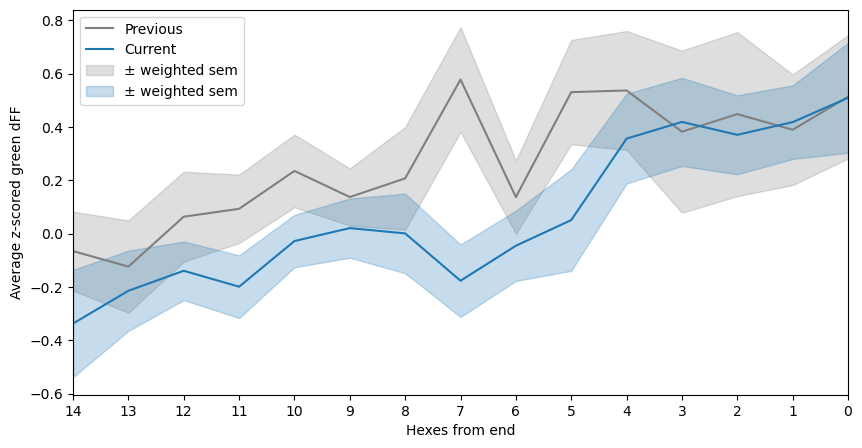

In [24]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}


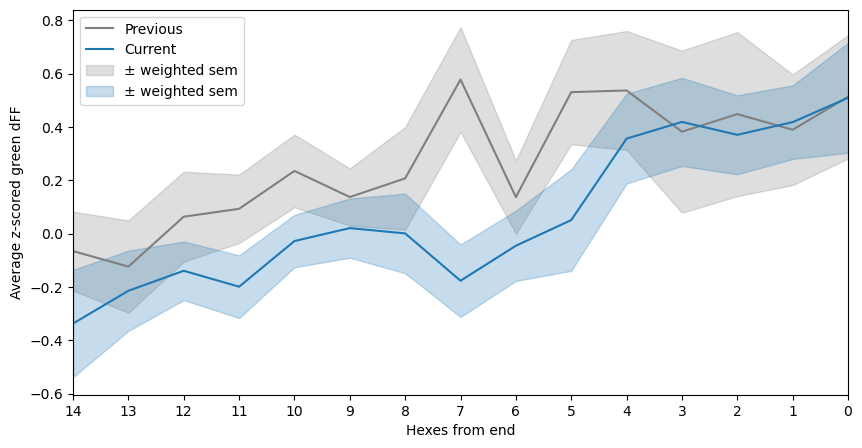

In [25]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

# Speed plot
1. Directly using epoch_df and it's duration with size of the hex (13 cm)


In [26]:
def add_speed_column_by_duration(HexPath_df, new_col_name: str, hex_size: int = 13):
    """
    Add a speed column computed as hex_size / duration.
    Args:
        HexPath_df: DataFrame with a 'duration' column.
        new_col_name: name for the new speed column.
        hex_size: size (distance) of a hex (default 13).
    """
    df = HexPath_df.copy()
    speeds = []

    for _, row in df.iterrows():
        duration = row.get('duration', np.nan)
        try:
            duration = float(duration)
        except Exception:
            duration = np.nan

        if np.isfinite(duration) and duration > 0:
            speed = hex_size / duration
        else:
            speed = np.nan

        speeds.append(speed)

    df[new_col_name] = speeds
    return df

In [27]:
epoch_df_dff_speed = add_speed_column_by_duration(epoch_df_dff, hex_size=13, new_col_name='speed')
epoch_df_dff_speed

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF,speed
id,,,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen,1.479858,84.821917
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen,3.024351,47.890307
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen,3.472468,26.081291
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen,2.117566,174.481641
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen,3.492153,23.481785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen,-0.200930,62.461966
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen,-0.035684,162.465063
3905,IM-1594_20230727_.nwb,0,3,12,138,5,6665.001283,6665.208629,0.207346,17,1,12,2,optimal,chosen,0.365923,62.697191


In [28]:
speed_by_hexes_from_end = group_series_by_hexes_from_end(epoch_df_dff_speed, series_col='speed', hex_type=['optimal','choice_point'])
display(speed_by_hexes_from_end)

/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,3.289950,0.440714,139.0,549.248444
1,68.861798,8.187652,130.0,24.541909
2,59.292486,4.801868,123.0,26.968004
3,57.733243,5.751432,101.0,22.742530
4,10.806915,6.379780,141.0,169.613619
5,21.957087,5.813665,150.0,88.809597
6,3.564702,1.862257,238.0,867.954841
7,13.595664,2.925352,217.0,207.492624
8,5.552049,2.214906,277.0,648.589331


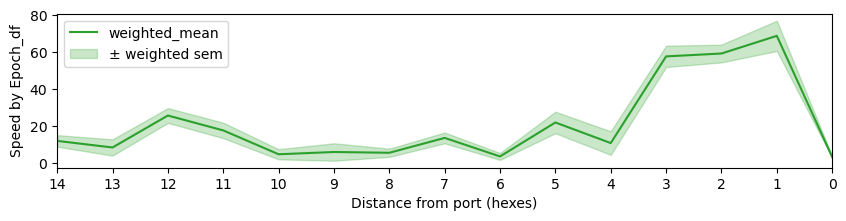

In [29]:
plot_series_during_port_approach(speed_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=False, max_hexes_from_end=14, figtitle='Speed by Epoch_df', figsize=(10,2)) 

2. Using velocity data from HexPosition table

In [30]:
from hex_maze_behavior import HexPosition

pos_key = {
    'pos_merge_id': "cfe6c111-1aa1-a41d-858c-f307e7a53b7c", 
    'nwb_file_name': 'IM-1478_20220726_.nwb', 
    'epoch': 0
}

display(HexPosition() & pos_key)

# Fetch rat's position + assigned hex
hex_and_pos_df = (HexPosition() & pos_key).fetch_hex_and_position_dataframe()
display(hex_and_pos_df)

pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_assignment_object_id
cfe6c111-1aa1-a41d-858c-f307e7a53b7c,IM-1478_20220726_.nwb,0,IM-1478_20220726_QVH88J6G2L.nwb,6713169f-da4e-412f-93c5-e709fce6ad7f


[18:52:41][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,hex_including_sides,distance_from_centroid
time,,,,,,,,,
49.924743,48.875865,126.927501,-2.828533,-6.552273,-11.494208,13.230612,49,49,6.594894
49.926743,48.855970,126.885491,-2.826981,-6.491748,-11.364589,13.088036,49,49,6.555677
49.928743,48.836074,126.843481,-2.825451,-6.430658,-11.232507,12.943052,49,49,6.516555
49.930743,48.816178,126.801471,-2.823943,-6.369021,-11.098029,12.795729,49,49,6.477530
49.932743,48.796282,126.759461,-2.822456,-6.306857,-10.961224,12.646141,49,49,6.438604
...,...,...,...,...,...,...,...,...,...
4373.816606,33.987062,129.762182,2.767999,5.172852,-6.221110,8.090773,2,2,6.777932
4373.818606,34.000927,129.758267,2.770006,5.240502,-6.331527,8.218947,2,2,6.763533
4373.820606,34.014791,129.754352,2.772013,5.307450,-6.441350,8.346258,2,2,6.749134


In [31]:
def add_averaged_speed_column(HexPath_df, HexPosition_df, new_col_name: str):
    """
    Calculate the average speed between each hex's entry_time and exit_time.

    Parameters:
    HexPath_df (pd.DataFrame): DataFrame containing hex path data with 'entry_time' and 'exit_time' columns.
    HexPosition_df (pd.DataFrame): DataFrame containing position data with timestamps and speed.

    Returns:
    pd.DataFrame: Updated DataFrame with a new column specified by col_name.
    """
    df = HexPath_df.copy()
    avg_series_list = []

    timestamps = HexPosition_df.index.values
    data = HexPosition_df.speed.values

    for _, row in df.iterrows():
        entry_time = row['entry_time']
        exit_time = row['exit_time']

        # Find indices of timestamps within the entry and exit time
        indices = np.where((timestamps >= entry_time) & (timestamps <= exit_time))[0]

        if len(indices) > 0:
            avg_speed = np.mean(data[indices])
        else:
            avg_speed = np.nan  # No data in this interval

        avg_series_list.append(avg_speed)

    df[new_col_name] = avg_series_list
    return df

In [32]:
epoch_df_dff_speed_avg = add_averaged_speed_column(epoch_df_dff_speed, hex_and_pos_df, new_col_name='avg_speed')
epoch_df_dff_speed_avg

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF,speed,avg_speed
id,,,,,,,,,,,,,,,,,,
0,IM-1594_20230727_.nwb,0,1,1,1,36,17.127463,17.280725,0.153262,1,1,-1,8,optimal,chosen,1.479858,84.821917,NaN
1,IM-1594_20230727_.nwb,0,1,1,1,30,17.351929,17.623383,0.271454,2,1,-1,7,optimal,chosen,3.024351,47.890307,NaN
2,IM-1594_20230727_.nwb,0,1,1,1,35,17.694574,18.193016,0.498442,3,1,-1,6,optimal,chosen,3.472468,26.081291,NaN
3,IM-1594_20230727_.nwb,0,1,1,1,29,18.253110,18.327616,0.074506,4,1,-1,5,optimal,chosen,2.117566,174.481641,NaN
4,IM-1594_20230727_.nwb,0,1,1,1,34,18.400676,18.954297,0.553621,5,1,-1,4,optimal,chosen,3.492153,23.481785,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,IM-1594_20230727_.nwb,0,3,12,138,10,6664.584851,6664.792977,0.208127,15,1,10,4,optimal,chosen,-0.200930,62.461966,NaN
3904,IM-1594_20230727_.nwb,0,3,12,138,7,6664.856853,6664.936870,0.080017,16,1,11,3,optimal,chosen,-0.035684,162.465063,NaN
3905,IM-1594_20230727_.nwb,0,3,12,138,5,6665.001283,6665.208629,0.207346,17,1,12,2,optimal,chosen,0.365923,62.697191,NaN


In [33]:
avg_speed_by_hexes_from_end = group_series_by_hexes_from_end(epoch_df_dff_speed_avg, series_col='avg_speed', hex_type=['optimal','choice_point'])
display(avg_speed_by_hexes_from_end)

/tmp/ipykernel_3195720/487901835.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_col, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,10.045866,1.090621,94.0,366.656171
1,8.203817,2.268512,87.0,15.956442
2,13.200365,1.985812,86.0,18.301463
3,10.871560,1.825153,72.0,15.641953
4,9.088067,1.950662,96.0,67.202643
5,8.464593,1.787977,99.0,65.428183
6,8.318481,1.318693,151.0,602.634696
7,9.940485,1.603023,137.0,131.786674
8,7.575497,1.298209,207.0,552.849927


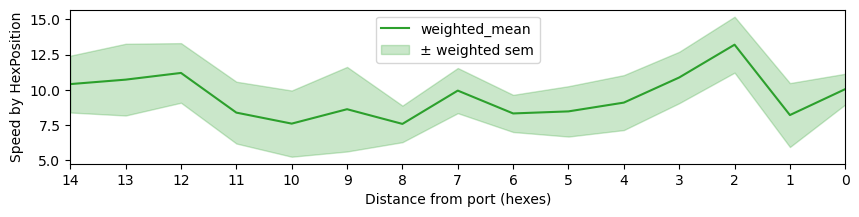

In [34]:
plot_series_during_port_approach(avg_speed_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=False, max_hexes_from_end=14, figtitle='Speed by HexPosition', figsize=(10,2)) 